# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

import warnings
warnings.filterwarnings('ignore')

# Part A: Conceptual Questions

### 1. What is a Decision Tree and how does it make decisions?
- A Decision Tree is a supervised machine learning algorithm used for classification and regression. It is a non-parametric model because it does not learn explicit weights or parameters; instead, it learns a set of decision rules directly from the data. The algorithm works by recursively splitting the dataset based on feature values in order to reduce impurity (or error).

- The topmost node is called the root node, and the feature chosen for the root is the one that provides the maximum reduction in impurity (using metrics such as Gini Impurity or Entropy). This splitting process continues until a stopping criterion is met, such as maximum depth, minimum samples per node, or no further impurity reduction. Predictions are made at the leaf nodes.

### 2. What does a split criterion mean in a Decision Tree?
- A split criterion is the metric used to evaluate how good a split is by measuring impurity or error at a node. It helps the tree decide which feature and where to split.

> Examples of split criteria:

- Gini Impurity
- Entropy (Information Gain)
- Log Loss
- MSE / MAE (for regression)

### 3. Difference between Gini Impurity and Entropy.
- Gini Impurity and Entropy are criteria used by a Decision Tree to evaluate the quality of splits by measuring node impurity.
- At each split (up to max_depth or other stopping criteria), the tree chooses the feature that reduces impurity the most.
- **Entropy** is `computationally more expensive due to logarithmic calculations`, while **Gini Impurity** is `computationally simpler and faster.`

### 4. Why do Decision Trees tend to overfit?

Decision Trees tend to overfit because, if allowed to grow deep without constraints, they keep splitting the data until the leaf nodes become very small or pure. In doing so, the tree starts memorizing individual data points instead of learning general patterns. This results in very high training accuracy but poor performance on unseen or test data, which is known as overfitting.

### 5. What role does the max_depth parameter play?
max_depth controls the maximum number of levels (depth) the decision tree is allowed to grow. It limits how many recursive splits the tree can make and directly controls the model’s complexity.

- Controls model complexity

- Small max_depth → shallow tree → simple rules

- Large max_depth → deep tree → complex rules

**This directly affects:**

- How detailed the learned patterns are

- Whether the tree learns patterns or memorizes data points

- Prevents overfitting

**If max_depth is not restricted:**

- Tree keeps splitting until leaves are pure

- Learns noise and outliers

- High training accuracy, low test accuracy

**By limiting depth:**

- Splitting stops early

- Leaves contain more samples

- Tree learns general patterns

- Depth controls how specific the questions in the tree become.

- **Too deep** → `memorization`.

- **Too shallow** → `oversimplification`

# Part B: Data Exploration

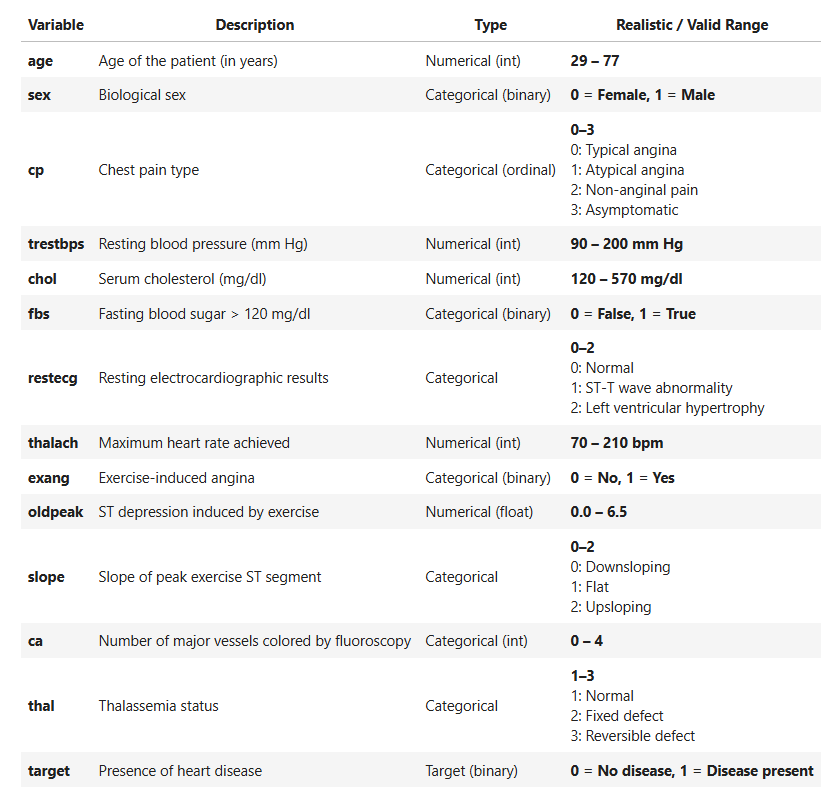

In [3]:
df = pd.read_csv(r"C:\Users\Ajay kumar\OneDrive\Documents\Innomatics\M5-Machine Learning\TASKS\TASK_7\heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
df.duplicated().sum()

723

In [11]:
df=df.drop_duplicates()

# Part C: Data Preprocessing

In [12]:
x=df.drop(columns={'target'})
y=df['target']

In [13]:
y.value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [14]:
x.shape
y.shape

(302, 13)

(302,)

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((241, 13), (61, 13), (241,), (61,))

# Part D: Model Building

#### criterion='gini'

In [17]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [18]:
dtc=DecisionTreeClassifier(criterion='gini',random_state=42)
dtc

DecisionTreeClassifier(random_state=42)

In [19]:
x_train_transformed=dtc.fit(x_train,y_train)
x_train_transformed

DecisionTreeClassifier(random_state=42)

In [20]:
dtc.score(x_train,y_train)

1.0

# Part E: Model Evaluation

In [21]:
y_pred=dtc.predict(x_test)
y_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1], dtype=int64)

In [22]:
from sklearn.metrics import accuracy_score

In [23]:
accuracy_score(y_test,y_pred)

0.8032786885245902

# Part F: Understanding Tree Depth (Manual Experiment)

#### Training three models by changing only max_depth:
#### max_depth=2

In [24]:
dtc1=DecisionTreeClassifier(max_depth=2,random_state=42)
dtc1

DecisionTreeClassifier(max_depth=2, random_state=42)

In [25]:
x_train_transformed=dtc1.fit(x_train,y_train)
x_train_transformed

DecisionTreeClassifier(max_depth=2, random_state=42)

In [26]:
dtc1.score(x_train,y_train)

0.7842323651452282

In [27]:
y_pred=dtc1.predict(x_test)
y_pred

array([0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1], dtype=int64)

In [28]:
accuracy_score(y_test,y_pred)

0.6557377049180327

#### max_depth=5

In [30]:
dtc2=DecisionTreeClassifier(max_depth=5,random_state=42)
dtc2

DecisionTreeClassifier(max_depth=5, random_state=42)

In [32]:
x_train_transformed=dtc2.fit(x_train,y_train)
x_train_transformed

DecisionTreeClassifier(max_depth=5, random_state=42)

In [33]:
dtc2.score(x_train,y_train)

0.941908713692946

In [34]:
y_pred=dtc2.predict(x_test)
y_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0], dtype=int64)

In [35]:
accuracy_score(y_test,y_pred)

0.7704918032786885

#### max_depth=None

In [36]:
dtc=DecisionTreeClassifier(random_state=42)
dtc

DecisionTreeClassifier(random_state=42)

In [37]:
x_train_transformed=dtc.fit(x_train,y_train)
x_train_transformed

DecisionTreeClassifier(random_state=42)

In [39]:
dtc.score(x_train,y_train)

1.0

In [40]:
y_pred=dtc.predict(x_test)
y_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1], dtype=int64)

In [41]:
accuracy_score(y_test,y_pred)

0.8032786885245902

---

#### 1.What happens when the tree is very shallow?

- A very shallow tree means:
    - Small max_depth
    - Few splits
    - Very simple rules

- Effects:
    - High bias
    - Model is too simple to capture patterns
    - Many different data points get the same prediction

- Performance:
    - Low training accuracy
    - Low testing accuracy

This is called **Underfitting**(Too simplistic for complex data.)

Ex: IF Age > 30 → Yes ELSE → No

#### 2. What happens when the tree is very deep?

- A very deep tree means:
    - Large or unlimited max_depth
    - Many splits
    - Very specific rules

- Effects:
    - Low bias
    - High variance
    - Model memorizes training data

- Performance:
    - ✅ Very high training accuracy (often 100%)
    - ❌ Low testing accuracy

This is called Overfitting (memorization.)

Ex: IF Age=27 AND Income=48732 AND Zip=500032 → Yes

#### 3. Which model performs best and why?

The best model is a moderately deep tree

- That means:
    - Not too shallow
    - Not too deep
    - Controlled complexity

- Why?
    - Captures meaningful patterns
    - Ignores noise
    - Balances bias and variance

- Performance:
    - Good training accuracy
    - Good testing accuracy
    - Best generalization
---
- **Note:**
    - **Too simple** → misses patterns
    - **Too complex** → memorizes noise
    - **Just right** → generalizes well
---

# Part G: Tree Visualization

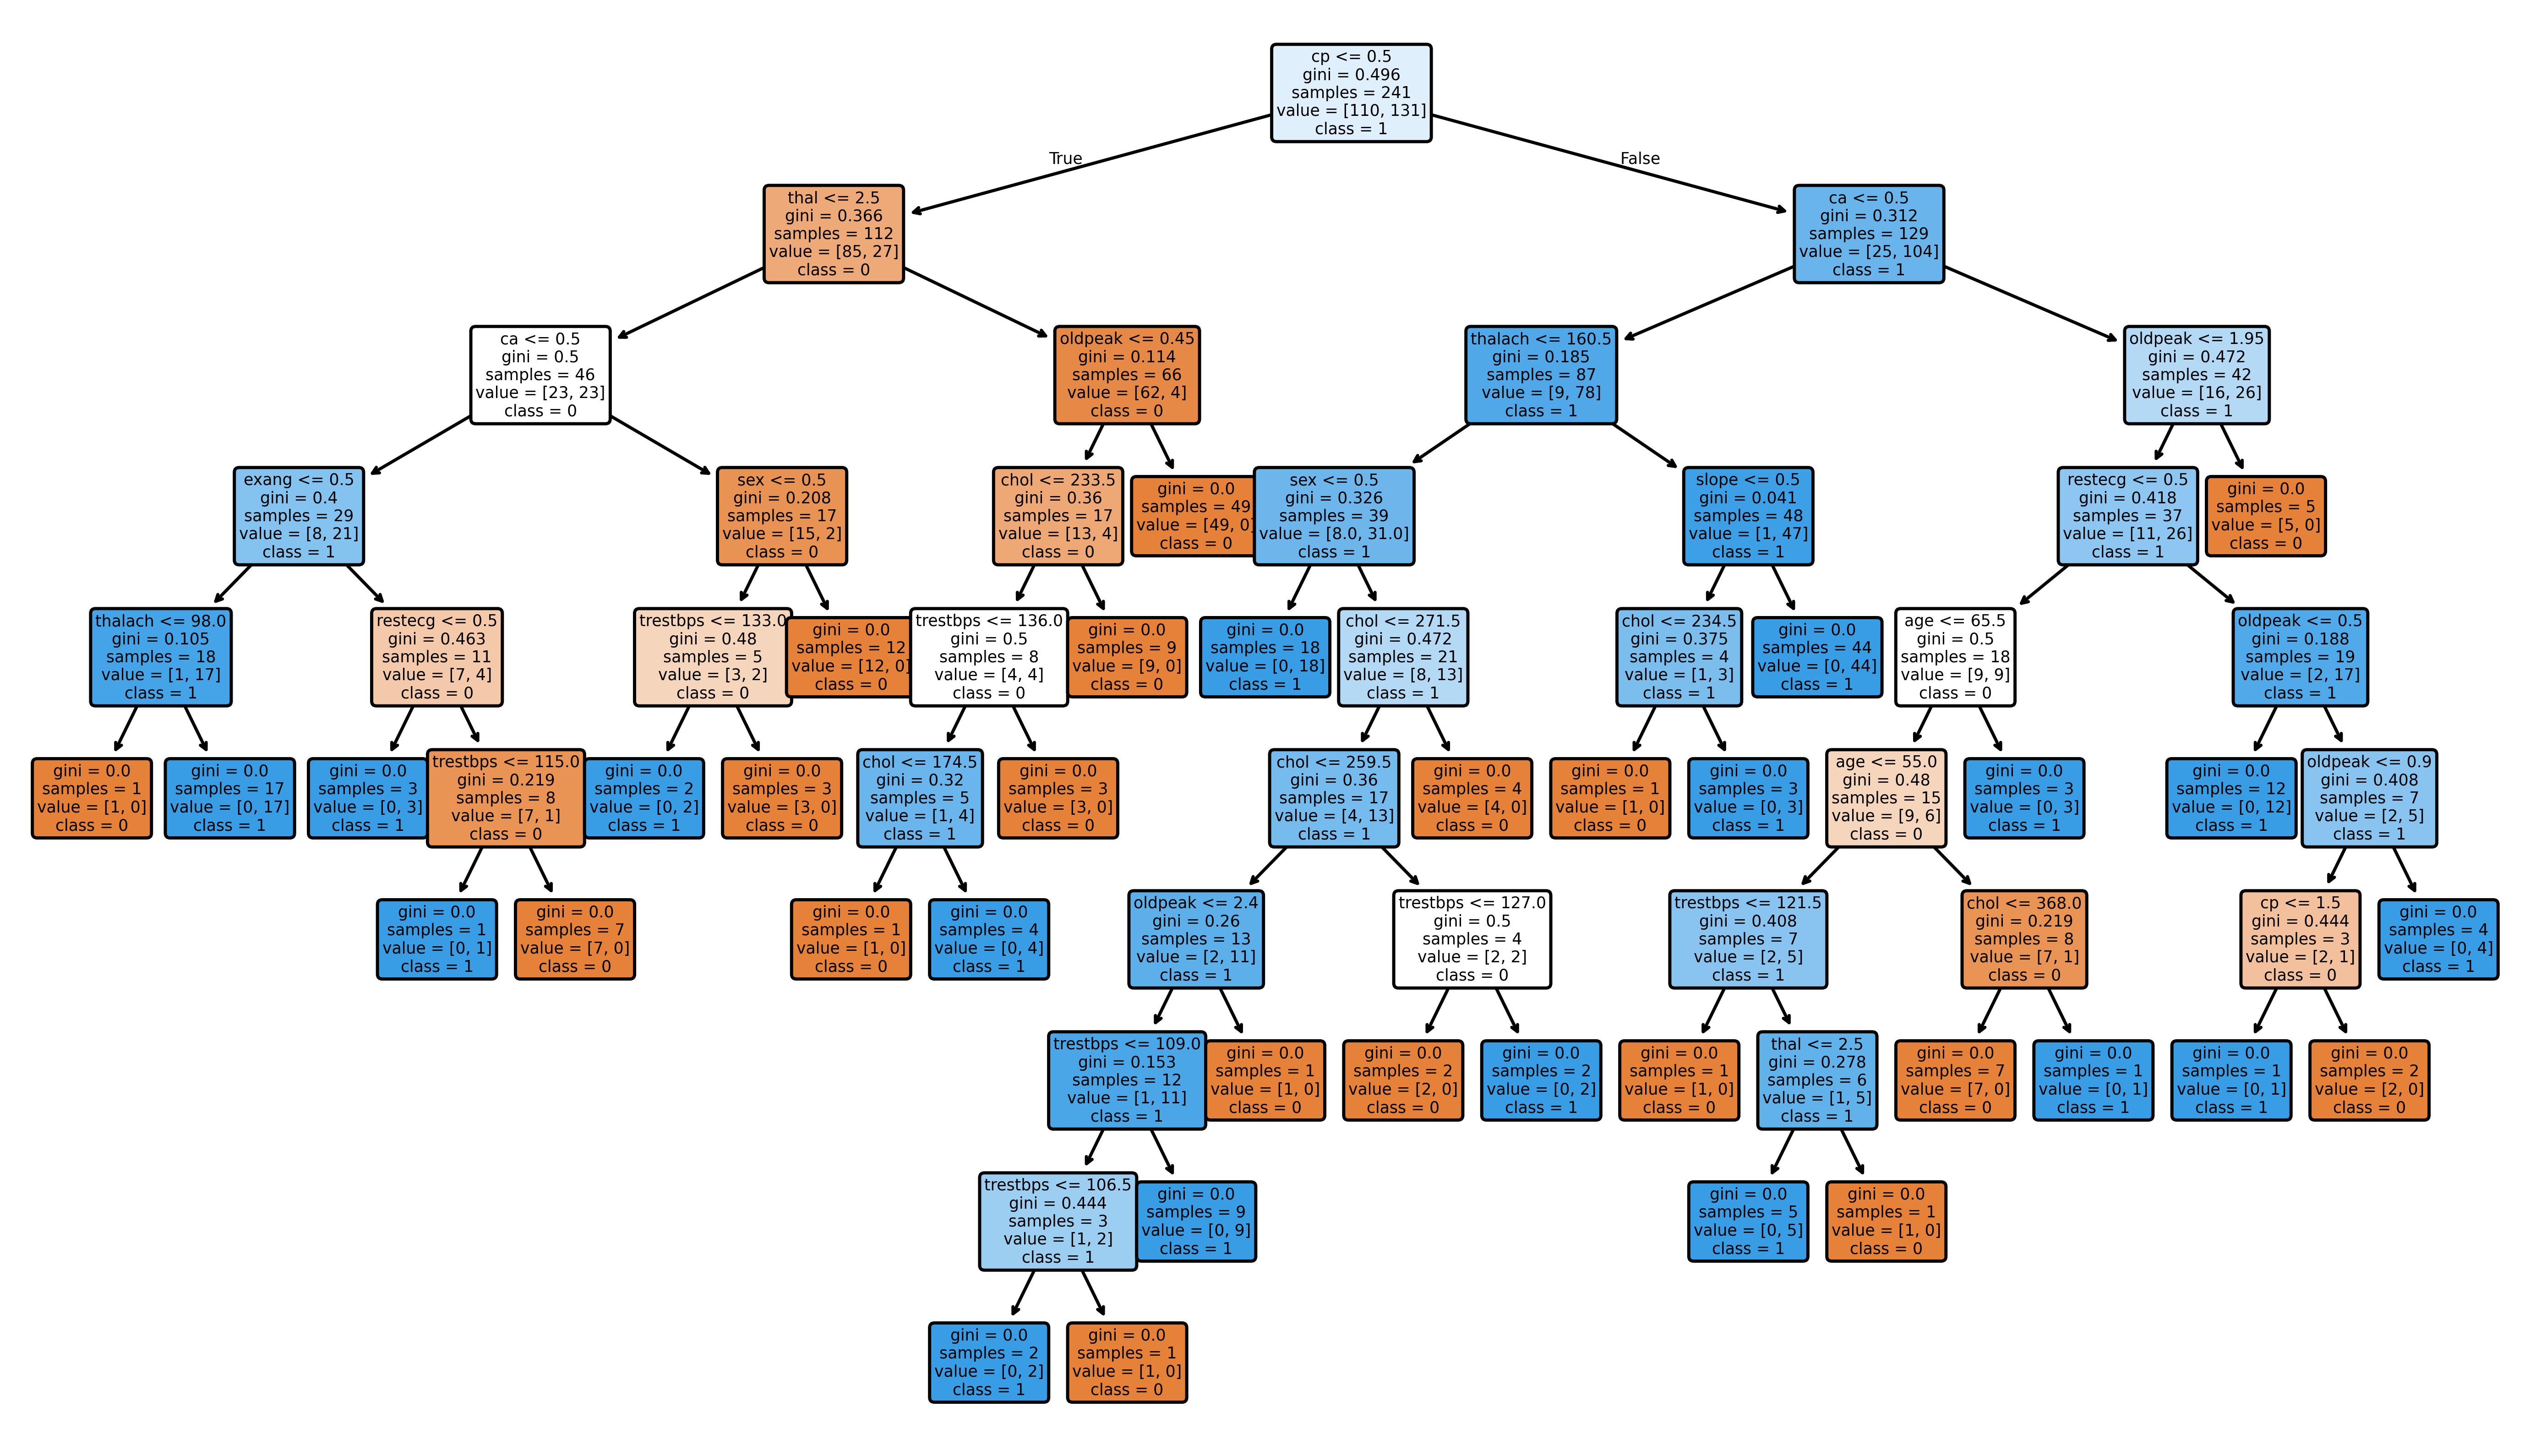

In [42]:
plt.figure(figsize=(14,8), dpi=500)
plot_tree(dtc,feature_names=x_train.columns,class_names=['0','1']
          ,filled=True,rounded=True,fontsize=5);

### changing the hyperparameters and checking training and testing performance

#### **criterion='entropy'**

In [43]:
dtc=DecisionTreeClassifier(criterion='entropy',random_state=42)
dtc

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [44]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [45]:
dtc.score(x_train,y_train)

1.0

In [46]:
y_pred=dtc.predict(x_test)
y_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0], dtype=int64)

In [47]:
accuracy_score(y_test,y_pred)

0.7213114754098361

**Note:**

I find some differnce in gini and entropy is that
- `DecisionTreeClassifier(criterion='entropy',random_state=42)` is giving training score of 1.0 and testing accuracy as 0.72, while
-  `DecisionTreeClassifier(criterion='gini',random_state=42)` is giving training score as 1.0 and testing accuracy 0.8.

That means DecisionTreeClassifier with criterion='Gini' is more generalizing than **criterion='entropy'**

#### min_samples_split=4

In [48]:
dtc=DecisionTreeClassifier(min_samples_split=5,random_state=42)
dtc

DecisionTreeClassifier(min_samples_split=5, random_state=42)

In [49]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier(min_samples_split=5, random_state=42)

In [50]:
dtc.score(x_train,y_train)

0.979253112033195

In [51]:
y_pred=dtc.predict(x_test)
y_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0], dtype=int64)

In [52]:
accuracy_score(y_test,y_pred)

0.7868852459016393

#### min_samples_split=10

In [53]:
dtc=DecisionTreeClassifier(min_samples_split=10,random_state=42)
dtc

DecisionTreeClassifier(min_samples_split=10, random_state=42)

In [54]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier(min_samples_split=10, random_state=42)

In [55]:
dtc.score(x_train,y_train)

0.9336099585062241

In [56]:
y_pred=dtc.predict(x_test)
y_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1], dtype=int64)

In [57]:
accuracy_score(y_test,y_pred)

0.8032786885245902

**Note:**
- Model for min_samples_split=10 is better generalizing for min_samples_split=5 because their training score and testing accuracy difference for min_samples_split=10 is less as compared to min_samples_split=5

#### min_samples_leaf=4

In [58]:
dtc=DecisionTreeClassifier(min_samples_leaf=4,random_state=42)
dtc

DecisionTreeClassifier(min_samples_leaf=4, random_state=42)

In [59]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier(min_samples_leaf=4, random_state=42)

In [60]:
dtc.score(x_train,y_train)

0.9253112033195021

In [61]:
y_pred=dtc.predict(x_test)
y_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1], dtype=int64)

In [62]:
accuracy_score(y_test,y_pred)

0.7540983606557377

#### min_samples_leaf=8

In [63]:
dtc=DecisionTreeClassifier(min_samples_leaf=8,random_state=42)
dtc

DecisionTreeClassifier(min_samples_leaf=8, random_state=42)

In [64]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier(min_samples_leaf=8, random_state=42)

In [65]:
dtc.score(x_train,y_train)

0.8838174273858921

In [66]:
y_pred=dtc.predict(x_test)
y_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1], dtype=int64)

In [67]:
accuracy_score(y_test,y_pred)

0.8032786885245902

**Note:**
- Model for min_samples_leaf=8 is better generalizing for min_samples_leaf=4 because their training score and testing accuracy difference for min_samples_leaf=8 is less as compared to min_samples_leaf=4

#### min_impurity_decrease=0.02

In [68]:
dtc=DecisionTreeClassifier(min_impurity_decrease=0.02,random_state=42)
dtc

DecisionTreeClassifier(min_impurity_decrease=0.02, random_state=42)

In [69]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier(min_impurity_decrease=0.02, random_state=42)

In [70]:
dtc.score(x_train,y_train)

0.8381742738589212

In [71]:
y_pred=dtc.predict(x_test)
y_pred

array([0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1], dtype=int64)

In [72]:
accuracy_score(y_test,y_pred)

0.7704918032786885

# Part H: Reflection Questions

#### 1. Why are Decision Trees suitable for medical datasets?

Decision Trees are well-suited for medical datasets because:

🔹 **Interpretability (Critical in healthcare)**

- Doctors must understand why a model made a prediction.

- Decision Trees provide clear decision paths (e.g., “If BP > 140 and Age > 50 → High Risk”).

🔹 **Handle Mixed Data Types**

- Medical data often contains:

- **Numerical** (age, blood pressure, glucose)

- **Categorical** (gender, symptoms, diagnosis codes)

Decision Trees handle both without feature scaling.

🔹 **Capture Non-linear Relationships**

- Medical conditions often depend on complex interactions between features.

- Trees naturally model non-linear and rule-based patterns.

🔹 **Robust to Outliers**

- Medical measurements can have noise or extreme values.

- Trees split on thresholds → less sensitive to outliers

🔹**Works with Missing Values (in some implementations)**

- Some tree variants can handle missing data or surrogate splits.

**Example:**

“If cholesterol > X and BMI > Y, then risk increases” This mirrors clinical decision rules.

#### 2. What makes Decision Trees easy to interpret?

- If–Else Logic
    - Each internal node represents a simple condition:
    - Is glucose > 140? Yes → High risk No → Low risk
- The features near the root are the most influential.
- Easy to explain which variables matter the most.

For any prediction, you can trace exactly which conditions were satisfied. This is known as model transparency.

> Human-Readable Rules

> Path Transparency

> Clear Feature Importance

> Decision Trees are easy to interpret because of their rule-based structure:

- Trees can be converted into:
    - IF age > 60 AND BP > 140 → Disease &rarr; Yes
- This aligns well with domain expertise (doctors, clinicians).
- Unlike black-box models (Neural Networks), trees explain how and why.

#### 3. Why are Decision Trees commonly used in ensemble methods?

Decision Trees are the building blocks of powerful ensemble models like Random Forests and Gradient Boosting.

🔹High Variance Learners

- A single tree tends to overfit.

- Ensembles reduce variance by combining many trees.

🔹 Diversity of Trees

- Trees can be made different by:

- Sampling data (bagging)

- Sampling features

Diversity improves ensemble performance.

🔹 Fast to Train

- Individual trees are computationally efficient.

- Makes them suitable for training hundreds or thousands of trees.

🔹 Non-parametric Nature

- Trees do not assume data distribution.

- Ensembles inherit this flexibility.

🔹 Strong Performance

- Models like:

    - Random Forest → reduces overfitting

    - XGBoost / LightGBM → state-of-the-art accuracy

Widely used in industry and healthcare analytics.

`Key idea:`
**Weak + unstable learners (trees)** → `Strong & stable ensemble`

#### **Summary Insight**

Decision Trees strike a practical balance between interpretability and predictive power, which explains their popularity in both standalone medical decision-support systems and ensemble-based models. They translate data into clinically understandable rules while remaining flexible enough to model complex relationships—a combination that is especially valuable in high-stakes fields like medicine.

 

# Final Experiments and Conclusion

### Comparison: Gini Impurity vs Entropy
To evaluate the effect of the split criterion, the Decision Tree was trained using both Gini impurity and Entropy, while keeping all other parameters unchanged (same train–test split, same random_state, same depth).

**Observation:**
The test accuracy and class-wise performance obtained using Gini and Entropy were very close, with no meaningful difference in prediction quality. In both cases, the model achieved high test accuracy (≈98–99%), and the confusion matrices showed only a few misclassifications.

**Interpretation:**
For this dataset, the choice of split criterion does not materially affect performance. Since Gini impurity is computationally simpler and produced results comparable to Entropy, it is a practical choice here. This confirms that model behavior is driven more by tree depth and data structure than by the impurity measure.

--- 

### Effect of `min_samples_leaf`
The **min_samples_leaf** parameter was adjusted manually to study its impact on model stability and overfitting.

**Observation:**
When min_samples_leaf was increased:
- Training accuracy decreased slightly compared to the unconstrained tree.
- Test accuracy remained stable and did not degrade significantly.
- The tree structure became less fragmented, with fewer very small leaf nodes.

**Interpretation:**
Enforcing a minimum number of samples per leaf prevents the model from learning overly specific rules based on very few samples. This reduces variance and improves robustness, even if it slightly limits training performance. This behavior is consistent with the bias–variance tradeoff.

--- 
### Final Conclusion

Across all experiments, tree complexity had the strongest impact on model performance:
- A shallow tree (max_depth = 2) underfit the data
(Train ≈ 77%, Test ≈ 72%).
- A moderately deep tree (max_depth = 5) achieved a good balance
(Train ≈ 93%, Test ≈ 87%).
- A fully grown tree (max_depth = None) perfectly fit the training data
(Train = 100%) and achieved very high test accuracy
(Test ≈ 98.5%), indicating mild overfitting.

Comparisons between **Gini vs Entropy** and experiments with **min_samples_leaf** showed that regularization choices help control overfitting, while impurity criteria have minimal effect for this dataset.

Overall, the Decision Tree model performs well on this medical classification task, offering strong predictive performance while remaining interpretable. `Careful control of tree depth and leaf size is essential to ensure generalization rather than memorization`.